In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from scipy.special import gamma

import numba

from lattice import Graphene


from matplotlib.patches import Polygon


import matplotlib.pyplot as plt

import numpy as np
from scipy.special import gamma
from scipy.sparse.linalg import expm_multiply
from scipy.sparse import bmat, diags, block_diag

import numba
from lattice import Graphene

from simulation import System, Eletric_field, Leg
from simulation import add_atom_to_hamiltonian, time_evolution

from utils import draw_basis_vectors, draw_electric_field, annotate_electric_field_text, separate_each_lattice, plot_graphene



PATH = "./plots/"

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Avenir', 'DejaVu Sans', 'Lucida Grande', 'Verdana']
plt.rcParams['font.size'] = 25
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 30  # x-axis tick labels
plt.rcParams['ytick.labelsize'] = 30 

In [3]:
def compute_position_legs(sys):
    a1 = sys.lattice.a1
    a2 = sys.lattice.a2
    R = []
    for leg in sys.legs:
        pos = leg.pos
        R.append(pos[0] * a1 + pos[1] * a2)
    return R


def compute_phase(r1, r2, tau):
    phi = 1 - 2 * tau / 3 * ((r2[0] - r1[0]) - (r2[1] - r1[1]))
    phi *= np.pi

    return phi

In [4]:
NMAX = 551
DELTA = 0.5
J = 1.
lambda_0 = 2
x0 = 0.
OMEGA_0 = 0.0
G = 0.3 / np.sqrt(2)
NUM_POINTS = 25
TF = 200

VALLEY = 1

leg1 = (0,0)
leg2 = (0,1)

print(f"Giant atom placed at \nr1 = {leg1}\nr2 = {leg2}")

PHI = compute_phase(leg1, leg2, VALLEY)

print(f"phi = {PHI}")
# PHI = np.pi/3


sys=System(
            lattice=Graphene(nmax=NMAX, J=J, x0=x0, delta_0=DELTA, lambda_0=lambda_0, pbc="y"),
            omega_0=OMEGA_0,
            g=G,
            legs=[
              Leg(site="A", pos=leg1),
              Leg(site="A", pos=leg2, phase=PHI),
            ]
    )

nx = range(- (NMAX // 2), NMAX // 2 + 1)
ny = range(- (NMAX // 2), NMAX // 2 + 1)

Nx, Ny = np.meshgrid(nx, ny)

na, nb = sys.lattice.n_real_pos

H = add_atom_to_hamiltonian(sys)
dim = H.shape[0]

t = np.linspace(0, TF, NUM_POINTS)

psi = np.zeros(dim, dtype=np.cdouble)
psi[-1] = 1. # Atom starts on excited state
psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)


psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

psi_a = psi_latt[:,:sys.lattice.la]
psi_b = psi_latt[:,sys.lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2

Giant atom placed at 
r1 = (0, 0)
r2 = (0, 1)
phi = 5.235987755982988


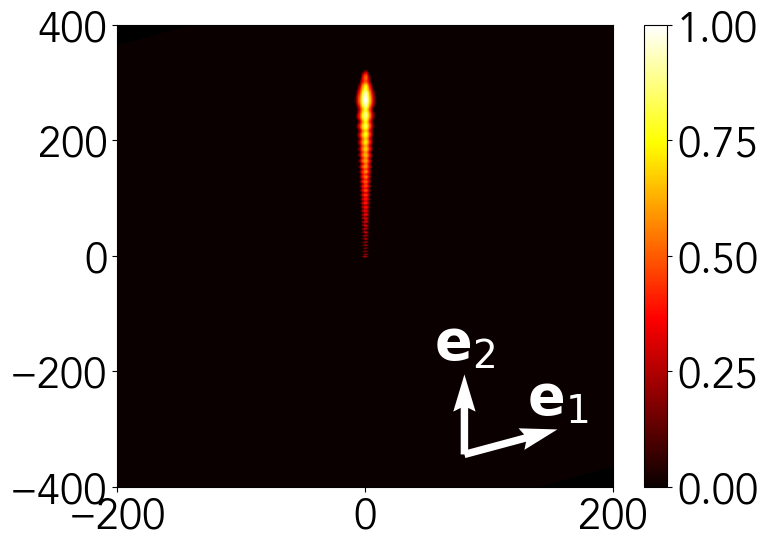

In [6]:
FIG_SIZE = (8, 6)
FILL = True
LOG_SCALE = True
VMAX = None
VMIN = -4.5


fig, ax = plt.subplots(figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], ax, s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE, rescale_to_0_1=True)

fig.colorbar(im, ax=ax, ticks=[0., 0.25, 0.5, 0.75, 1.])

if FILL:
    ax.set_facecolor("black")


ax.set_ylim(-400,400)
ax.set_xlim(-200, 200)

draw_basis_vectors(ax, [sys.lattice.a1, sys.lattice.a2], labels=(r"${\bf e}_1$", r"${\bf e}_2$"), pos=(0.7, 0.07), fontsize=40, scale=(50, 80), width=0.015)
plt.show()

fig.tight_layout()
# fig.savefig(PATH + "emission_giant_atom_phi=minus_piO3.pdf", bbox_inches="tight")

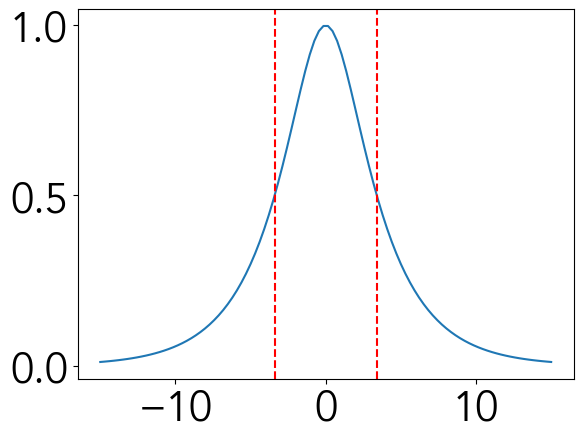

In [11]:
LAMBDA = 2
vf = 3/2
DELTA_0 = 0.5

XI = vf/DELTA_0

BETA = LAMBDA / XI

x = np.linspace(-15, 15, 100)

y = (1/np.cosh(x/LAMBDA)) ** (BETA)

plt.plot(x,y)

w1 = 2 * LAMBDA * np.arccosh(2**(1/BETA))

plt.axvline(-w1/2, color="red", linestyle="dashed")
plt.axvline(w1/2, color="red", linestyle="dashed")